# Forget

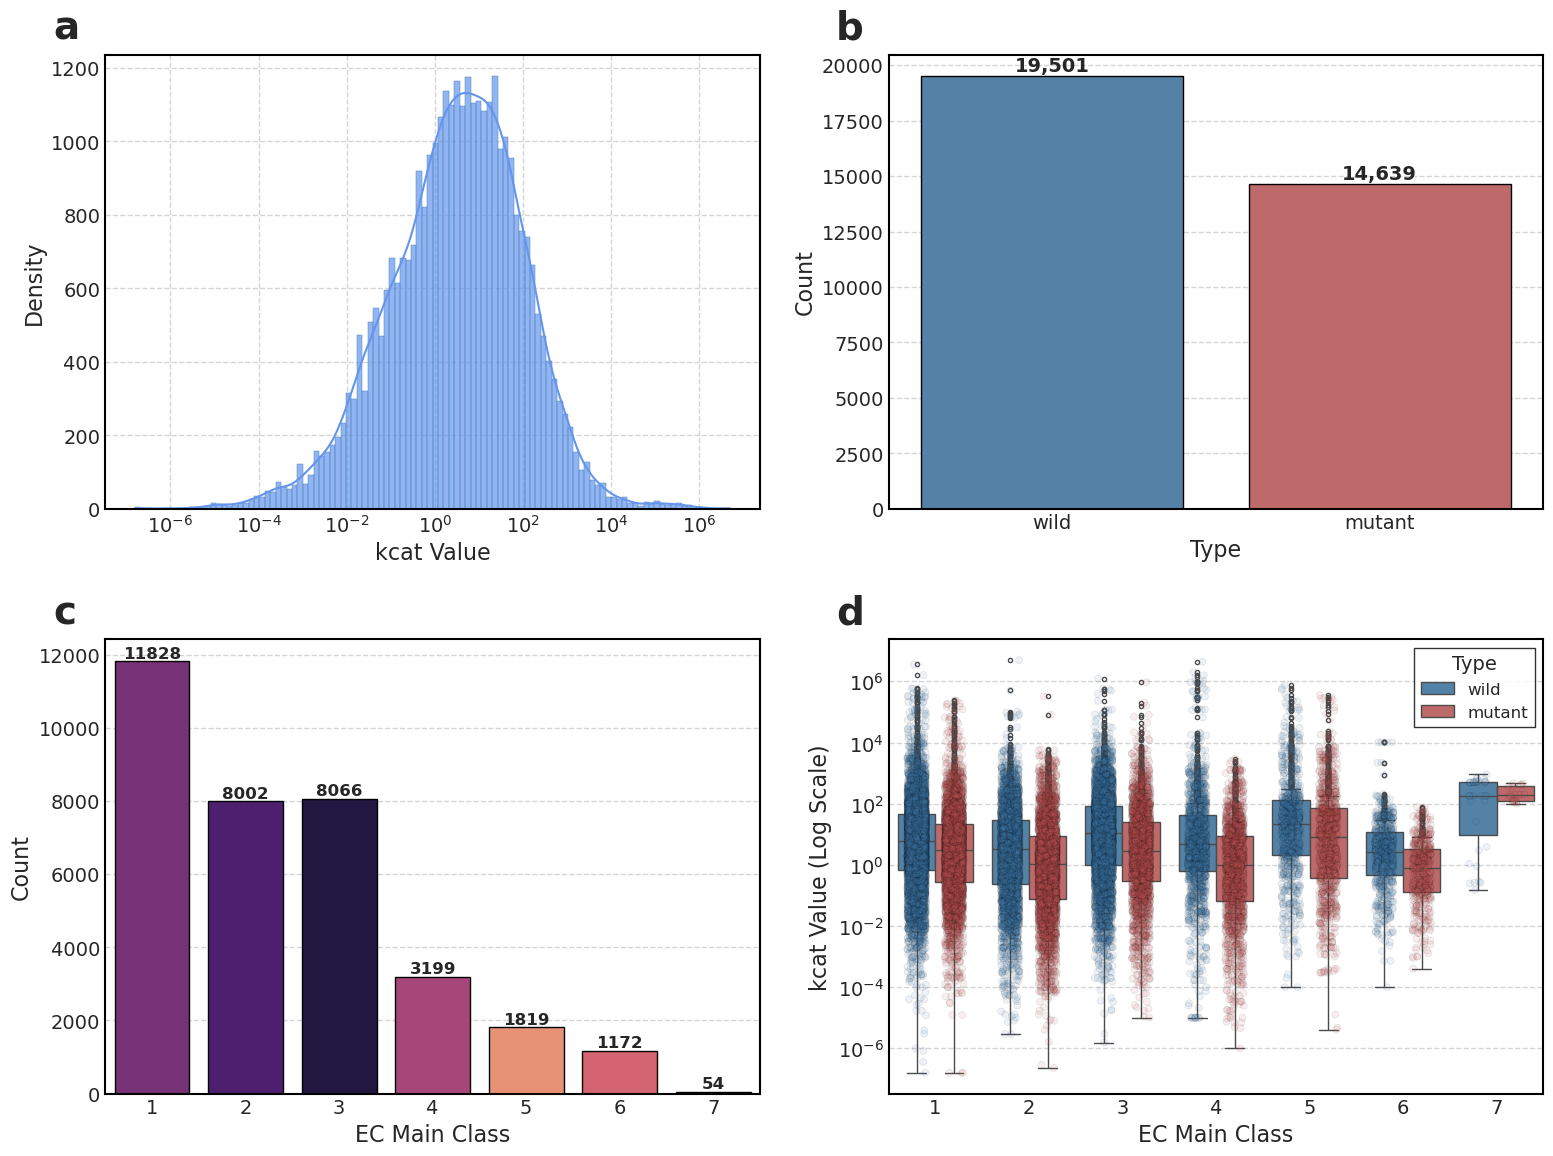

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Data
df = pd.read_csv('./Interkcat/EITLEM_KCAT.csv')
df['EC_Main_Class'] = df['ECNumber'].astype(str).str[0]

# Style
sns.set_theme(style="whitegrid", rc={
    "axes.grid": True,
    "grid.linestyle": "--",
    "grid.color": "#D5D5D5",
    "axes.edgecolor": "black",
    "axes.linewidth": 1.5,
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "legend.edgecolor": "black",
    "legend.fancybox": False,
})

plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial'] 
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
plt.rcParams['axes.unicode_minus'] = False 

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ==========================================
# Fig.a
# ==========================================
sns.histplot(df['Value'], kde=True, ax=axes[0, 0], log_scale=True, 
             color='#6495ED', edgecolor='#4682B4', alpha=0.7)
axes[0, 0].set_xlabel('kcat Value')
axes[0, 0].set_ylabel('Density')
axes[0, 0].text(-0.08, 1.10, 'a', transform=axes[0, 0].transAxes, fontsize=28, fontweight='bold', va='top')

# ==========================================
# Fig.b
# ==========================================
sns.countplot(data=df, x='type', hue='type', order=['wild', 'mutant'], 
              ax=axes[0, 1], palette=['#4682B4', '#CD5C5C'], legend=False,
              edgecolor='black', linewidth=1)
axes[0, 1].set_xlabel('Type')
axes[0, 1].set_ylabel('Count')

type_counts = df['type'].value_counts()
type_labels = ['wild', 'mutant']
for i, label in enumerate(type_labels):
    count = type_counts.get(label, 0)
    axes[0, 1].annotate(f'{count:,}', xy=(i, count + (df['type'].count()*0.001)), ha='center', va='bottom', fontsize=14, fontweight='bold')
axes[0, 1].text(-0.08, 1.10, 'b', transform=axes[0, 1].transAxes, fontsize=28, fontweight='bold', va='top')

# ==========================================
# Fig.c
# ==========================================
ec_order = sorted(df['EC_Main_Class'].unique())
sns.countplot(data=df, x='EC_Main_Class', hue='EC_Main_Class', order=ec_order, 
              ax=axes[1, 0], palette='magma', legend=False,
              edgecolor='black', linewidth=1)
axes[1, 0].set_xlabel('EC Main Class')
axes[1, 0].set_ylabel('Count')

for p in axes[1, 0].patches:
    axes[1, 0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height() + 5),
                        ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[1, 0].text(-0.08, 1.10, 'c', transform=axes[1, 0].transAxes, fontsize=28, fontweight='bold', va='top')

# ==========================================
# Fig.d
# ==========================================
sns.boxplot(data=df, x='EC_Main_Class', y='Value', hue='type', order=ec_order, 
            hue_order=['wild', 'mutant'], ax=axes[1, 1], 
            palette=['#4682B4', '#CD5C5C'], flierprops={'marker': '.'})
sns.stripplot(data=df, x='EC_Main_Class', y='Value', hue='type', order=ec_order, 
              hue_order=['wild', 'mutant'], ax=axes[1, 1], 
              palette=['#4682B4', '#CD5C5C'], dodge=True, alpha=0.1, jitter=0.2, legend=False, edgecolor='black', linewidth=0.5)

axes[1, 1].set_yscale('log')
axes[1, 1].set_xlabel('EC Main Class')
axes[1, 1].set_ylabel('kcat Value (Log Scale)')
axes[1, 1].legend(title='Type', loc='upper right', title_fontsize=14, fontsize=12)
axes[1, 1].text(-0.08, 1.10, 'd', transform=axes[1, 1].transAxes, fontsize=28, fontweight='bold', va='top')
plt.tight_layout(pad=2.0)
# plt.savefig("./Interkcat/Figure/SI_Distribution_of_EITLEM_Dataset.png", dpi=600, bbox_inches='tight', transparent=True)
plt.show()

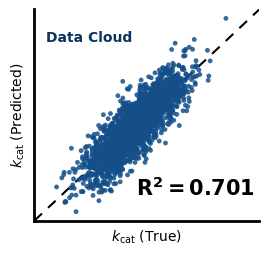

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.font_manager as fm

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Arial'
plt.rcParams['mathtext.it'] = 'Arial:italic'
plt.rcParams['mathtext.bf'] = 'Arial:bold'
plt.rcParams['axes.linewidth'] = 2.0

np.random.seed(42)
n_points = 2500
x_true = np.random.normal(loc=10, scale=2.5, size=n_points)
noise = np.random.normal(loc=0, scale=1.6, size=n_points)
y_pred = x_true + noise

min_val = min(x_true.min(), y_pred.min()) - 1
max_val = max(x_true.max(), y_pred.max()) + 1

fig, ax = plt.subplots(figsize=(3, 3.25))
ax.plot([min_val, max_val], [min_val, max_val], 
        color='black', linestyle='--', linewidth=1.5, dashes=(5, 4), zorder=1)

ax.scatter(x_true, y_pred, 
           color='#144f8a', s=12, alpha=0.85, edgecolors='none', zorder=2)

ax.set_xlim(min_val, max_val)
ax.set_ylim(min_val, max_val)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xticks([])
ax.set_yticks([])

ax.set_xlabel(r'$\it{k}_{\mathrm{cat}}$ (True)', fontsize=10, labelpad=5)
ax.set_ylabel(r'$\it{k}_{\mathrm{cat}}$ (Predicted)', fontsize=10, labelpad=5)

ax.text(min_val + 0.05*(max_val-min_val), max_val - 0.15*(max_val-min_val), 
        'Data Cloud', fontsize=10, color='#0a3360', fontweight='bold')

ax.text(max_val - 0.02*(max_val-min_val), min_val + 0.1*(max_val-min_val), 
        r'$\mathbf{R^2 = 0.701}$', fontsize=15, ha='right', va='bottom', color='black')

plt.subplots_adjust(left=0.15, right=0.9, top=0.85, bottom=0.2)
# plt.savefig('./Interkcat/Figure/TOC_Graphic_1.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

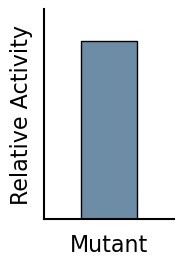

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as patches
from matplotlib.path import Path

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['axes.linewidth'] = 1.5

fig2, ax2 = plt.subplots(figsize=(2, 3))
prot_color = '#6d8da6'
ax2.bar([0], [0.85], color=prot_color, width=0.6, edgecolor='black', linewidth=1.0)
ax2.set_xlim(-0.7, 0.7)
ax2.set_ylim(0, 1)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.set_xticks([0])
ax2.set_yticks([])
ax2.set_xticklabels(['Mutant'], fontsize=16)
ax2.tick_params(axis='x', length=0, pad=10) 
ax2.set_ylabel('Relative Activity', fontsize=16, labelpad=8)

plt.subplots_adjust(left=0.25, right=0.9, top=0.9, bottom=0.2)
# plt.savefig('./Interkcat/Figure/TOC_Graphic_3.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

/tmp/ipykernel_444604/377175450.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Group', y='Test_R2', data=df_melted, ax=ax,


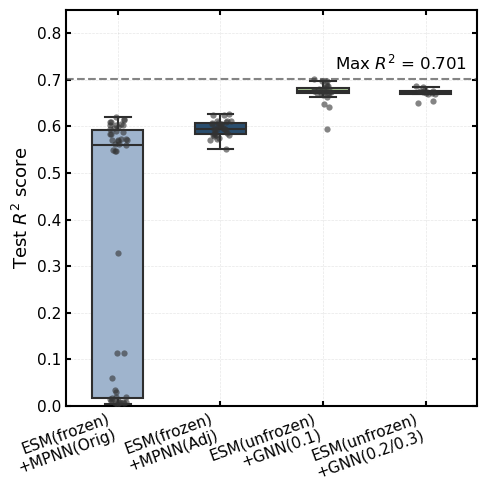

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'axes.labelsize': 13, 
    'xtick.labelsize': 11,         
    'ytick.labelsize': 11,
    'axes.linewidth': 1.5, 
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
})

# Data
file_path = "./Interkcat/hyperparameters.xlsx"
try:
    df_hyper = pd.read_excel(file_path, header=2)
except:
    df_hyper = pd.read_csv("hyperparameters.xlsx - Sheet1.csv", header=2)

group1 = pd.to_numeric(df_hyper['TEST_R2'].dropna(), errors='coerce').dropna()
group2 = pd.to_numeric(df_hyper['TEST_R2.1'].dropna(), errors='coerce').dropna()
group3 = pd.to_numeric(df_hyper[df_hyper['Dropout_rate'] == 0.1]['TEST_R2.2'].dropna(), errors='coerce').dropna()
group4 = pd.to_numeric(df_hyper[df_hyper['Dropout_rate.1'].isin([0.2, 0.3])]['TEST_R2.3'].dropna(), errors='coerce').dropna()

data = []
labels = ['ESM(frozen)\n+MPNN(Orig)', 'ESM(frozen)\n+MPNN(Adj)', 'ESM(unfrozen)\n+GNN(0.1)', 'ESM(unfrozen)\n+GNN(0.2/0.3)']

for val in group1: data.append({'Group': labels[0], 'Test_R2': val})
for val in group2: data.append({'Group': labels[1], 'Test_R2': val})
for val in group3: data.append({'Group': labels[2], 'Test_R2': val})
for val in group4: data.append({'Group': labels[3], 'Test_R2': val})
df_melted = pd.DataFrame(data)

fig, ax = plt.subplots(figsize=(5, 5))
colors = ['#98B4D4', '#1F4E79', '#A9D18E', '#F4B183']

sns.boxplot(x='Group', y='Test_R2', data=df_melted, ax=ax,
            palette=colors, width=0.5, linewidth=1.5, fliersize=0)

sns.stripplot(x='Group', y='Test_R2', data=df_melted, ax=ax,
              color='#333333', alpha=0.6, size=4.5, jitter=True)

ax.set_xlabel('')
ax.set_ylabel('Test $R^2$ score')
ax.set_ylim(0.0, 0.85)
ax.tick_params(top=True, right=True, direction='in')
plt.xticks(rotation=20, ha='right')

max_r2 = df_melted['Test_R2'].max()
ax.axhline(y=max_r2, color='#666666', linestyle='--', alpha=0.8, linewidth=1.5)

ax.text(x=3.4, y=max_r2 + 0.015, s=f'Max $R^2$ = {max_r2:.3f}',
        va='bottom', ha='right', fontsize=12, color='black')

ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.3)

plt.tight_layout()
# plt.savefig('./Interkcat/Figure/F3_A.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

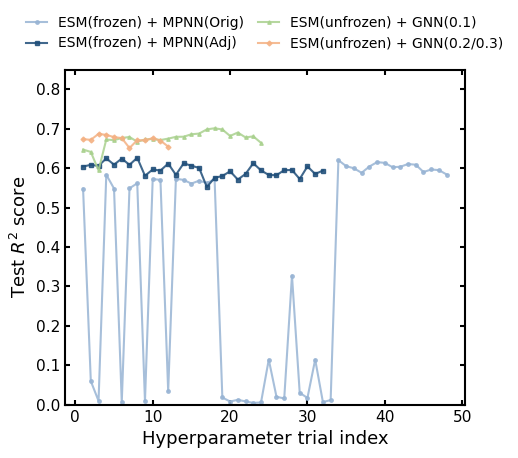

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'axes.labelsize': 13, 
    'xtick.labelsize': 11,         
    'ytick.labelsize': 11,
    'axes.linewidth': 1.5,
    'lines.linewidth': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
})

# Data
file_path = "./Interkcat/hyperparameters.xlsx"
try:
    df_hyper = pd.read_excel(file_path, header=2) 
except:
    df_hyper = pd.read_csv("hyperparameters.xlsx - Sheet1.csv", header=2)

group1 = pd.to_numeric(df_hyper['TEST_R2'].dropna(), errors='coerce').dropna()
group2 = pd.to_numeric(df_hyper['TEST_R2.1'].dropna(), errors='coerce').dropna()
group3 = pd.to_numeric(df_hyper[df_hyper['Dropout_rate'] == 0.1]['TEST_R2.2'].dropna(), errors='coerce').dropna()
group4 = pd.to_numeric(df_hyper[df_hyper['Dropout_rate.1'].isin([0.2, 0.3])]['TEST_R2.3'].dropna(), errors='coerce').dropna()


fig, ax = plt.subplots(figsize=(5, 5))

colors = ['#98B4D4', '#1F4E79', '#A9D18E', '#F4B183']
markers = ['o', 's', '^', 'D']
labels = ['ESM(frozen) + MPNN(Orig)', 
          'ESM(frozen) + MPNN(Adj)', 
          'ESM(unfrozen) + GNN(0.1)', 
          'ESM(unfrozen) + GNN(0.2/0.3)']

for i, g in enumerate([group1, group2, group3, group4]):
    ax.plot(range(1, len(g)+1), g, marker=markers[i], markersize=2.5, 
            linestyle='-', color=colors[i], alpha=0.85, label=labels[i])

ax.set_xlabel('Hyperparameter trial index')
ax.set_ylabel('Test $R^2$ score')
ax.set_ylim(0.0, 0.85)
ax.tick_params(top=True, right=True, direction='in')
ax.legend(loc='lower center', bbox_to_anchor=(0.5, 1.02), 
          frameon=False, fontsize=10, ncol=2, 
          handlelength=1.5, columnspacing=1.0)


plt.subplots_adjust(top=0.82, bottom=0.15, left=0.15, right=0.95)
# plt.savefig('./Interkcat/Figure/F3_B.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

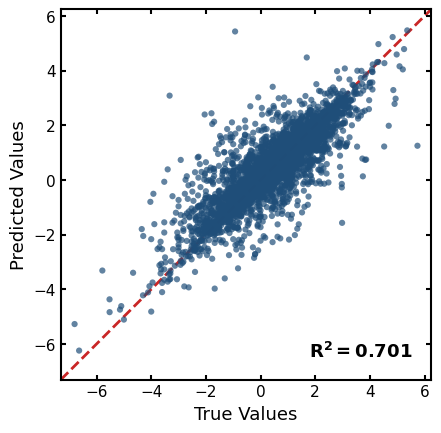

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

plt.style.use('default')
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'axes.labelsize': 13,
    'xtick.labelsize': 11,         
    'ytick.labelsize': 11,
    'axes.linewidth': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
})

# Data
file_path = "./Interkcat/model_test_performance.csv"
try:
    df_perf = pd.read_csv(file_path)
except FileNotFoundError:
    df_perf = pd.read_csv("model_test_performance.csv")

all_val_preds = df_perf['Predicted']
all_val_targets = df_perf['Actual']

r2 = r2_score(all_val_targets, all_val_preds)

fig, ax = plt.subplots(figsize=(4.5, 4.5))

ax.scatter(all_val_targets, all_val_preds, 
           s=20, c='#1F4E79', alpha=0.7, edgecolors='none', zorder=2)

lims = [
    min(all_val_preds.min(), all_val_targets.min()) - 0.5,
    max(all_val_preds.max(), all_val_targets.max()) + 0.5
]

ax.plot(lims, lims, color='#C00000', linestyle='--', linewidth=2.0, 
        alpha=0.85, zorder=1)

ax.set_aspect('equal')
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel('True Values')
ax.set_ylabel('Predicted Values')
ax.tick_params(top=True, right=True, direction='in')
ax.text(0.95, 0.05, rf'$\mathbf{{R^2 = {r2:.3f}}}$', transform=ax.transAxes, 
        fontsize=13, va='bottom', ha='right', color='black')
=
plt.tight_layout()
# plt.savefig('./Interkcat/Figure/F3_C.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

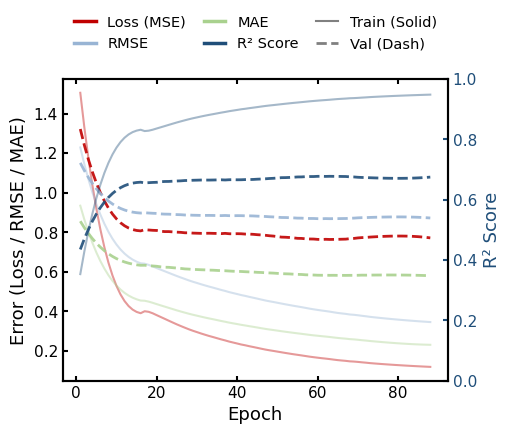

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from scipy.signal import savgol_filter

plt.style.use('default')
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'axes.labelsize': 13,
    'xtick.labelsize': 11,         
    'ytick.labelsize': 11,
    'axes.linewidth': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
})

# Data
file_path = "./Interkcat/training_metrics.csv"
try:
    df_train = pd.read_csv(file_path)
except FileNotFoundError:
    df_train = pd.read_csv("training_metrics.csv")

epochs = df_train['Epoch']

def smooth(y, window=31, poly=3):
    w = min(window, len(y))
    if w % 2 == 0: w -= 1
    if w <= poly: return y
    return savgol_filter(y, window_length=w, polyorder=poly)

fig, ax = plt.subplots(figsize=(5.5, 4.5))

c_loss = '#C00000' 
c_rmse = '#98B4D4'
c_mae  = '#A9D18E'
c_r2   = '#1F4E79'

ax.plot(epochs, smooth(df_train['Train_Loss']), color=c_loss, ls='-', alpha=0.4, lw=1.5)
ax.plot(epochs, smooth(df_train['Val_Loss']), color=c_loss, ls='--', alpha=0.9, lw=2.0)

ax.plot(epochs, smooth(df_train['Train_RMSE']), color=c_rmse, ls='-', alpha=0.4, lw=1.5)
ax.plot(epochs, smooth(df_train['Val_RMSE']), color=c_rmse, ls='--', alpha=0.9, lw=2.0)

ax.plot(epochs, smooth(df_train['Train_MAE']), color=c_mae, ls='-', alpha=0.4, lw=1.5)
ax.plot(epochs, smooth(df_train['Val_MAE']), color=c_mae, ls='--', alpha=0.9, lw=2.0)

ax.set_xlabel('Epoch')
ax.set_ylabel('Error (Loss / RMSE / MAE)')

ax.tick_params(top=True, direction='in')
ax2 = ax.twinx() 

ax2.plot(epochs, smooth(df_train['Train_R2']), color=c_r2, ls='-', alpha=0.4, lw=1.5)
ax2.plot(epochs, smooth(df_train['Val_R2']), color=c_r2, ls='--', alpha=0.9, lw=2.0)

ax2.set_ylabel('R² Score', color=c_r2)
ax2.set_ylim(0.0, 1.0)

ax2.tick_params(direction='in', colors=c_r2) 

legend_elements = [
    mlines.Line2D([0], [0], color=c_loss, lw=2.5, label='Loss (MSE)'),
    mlines.Line2D([0], [0], color=c_rmse, lw=2.5, label='RMSE'),
    mlines.Line2D([0], [0], color=c_mae, lw=2.5, label='MAE'),
    mlines.Line2D([0], [0], color=c_r2, lw=2.5, label='R² Score'),
    mlines.Line2D([0], [0], color='gray', lw=1.5, ls='-', label='Train (Solid)'),
    mlines.Line2D([0], [0], color='gray', lw=2.0, ls='--', label='Val (Dash)')
]

ax.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, 1.05), 
          ncol=3, frameon=False, fontsize=10.5, columnspacing=1.2, handlelength=1.5)

plt.subplots_adjust(top=0.82, bottom=0.15, left=0.15, right=0.85)
# plt.savefig('./Interkcat/Figure/F3_D.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

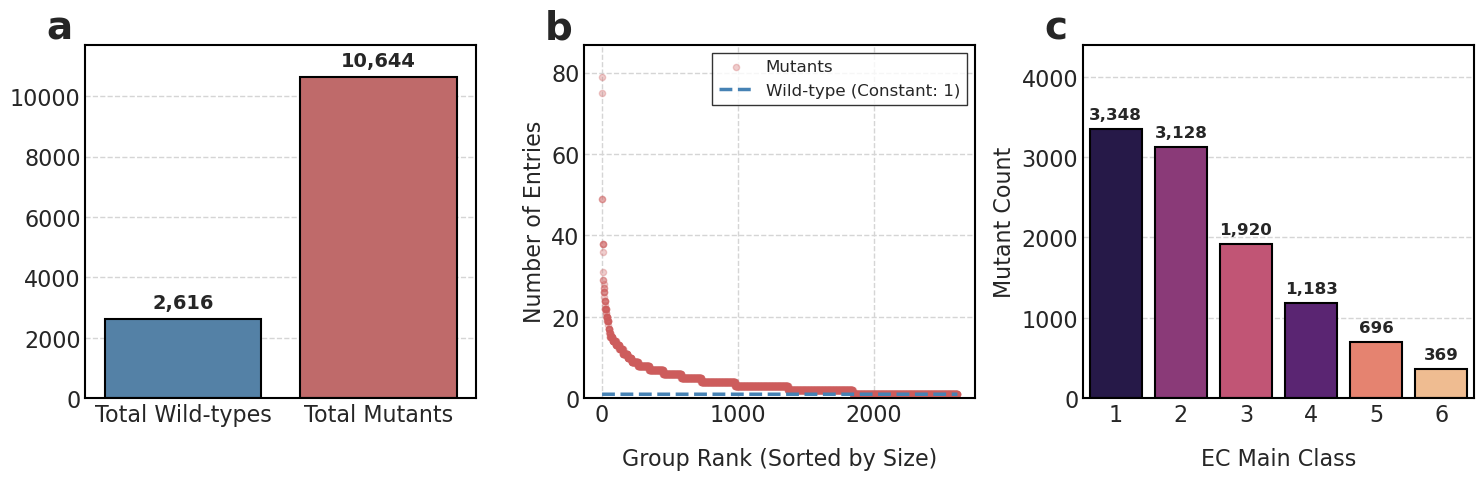

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Data
df = pd.read_csv('./Interkcat/Mutant-info.csv')
df = df.dropna(subset=['ECNumber'])
df['EC_Main_Class'] = df['ECNumber'].astype(str).str[0]
mutants_per_group = df['Group_ID'].value_counts().values
total_groups = len(mutants_per_group)
total_mutants = len(df)
total_wts = total_groups

# Style
sns.set_theme(style="whitegrid", rc={
    "axes.grid": True,
    "grid.linestyle": "--",
    "grid.color": "#D5D5D5",
    "axes.edgecolor": "black",
    "axes.linewidth": 1.5,
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.direction": "in",
    "ytick.direction": "in",
})

plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'sans-serif'] 
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 16
plt.rcParams['ytick.labelsize'] = 16
plt.rcParams['axes.unicode_minus'] = False 

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Figure a
categories = ['Total Wild-types', 'Total Mutants']
counts = [total_wts, total_mutants]

sns.barplot(x=categories, y=counts, hue=categories, ax=axes[0], 
            palette=['#4682B4', '#CD5C5C'], edgecolor='black', linewidth=1.5, legend=False)

for i, count in enumerate(counts):
    axes[0].annotate(f'{count:,}', xy=(i, count), xytext=(0, 5), textcoords='offset points', 
                     ha='center', va='bottom', fontsize=14, fontweight='bold')
axes[0].text(-0.1, 1.10, 'a', transform=axes[0].transAxes, fontsize=28, fontweight='bold', va='top')
axes[0].set_ylim(0, max(counts)*1.1)

# Figure b
x_rank = np.arange(1, total_groups + 1)

axes[1].scatter(x_rank, mutants_per_group, color='#CD5C5C', alpha=0.3, s=20, label='Mutants')

axes[1].plot(x_rank, np.ones(total_groups), color='#4682B4', linestyle='--', 
             linewidth=2.5, label='Wild-type (Constant: 1)')

axes[1].set_xlabel('Group Rank (Sorted by Size)', labelpad=15)
axes[1].set_ylabel('Number of Entries')
axes[1].legend(loc='upper right', fontsize=12, frameon=True, edgecolor='black', fancybox=False)
axes[1].set_ylim(0, max(mutants_per_group) * 1.1)

axes[1].text(-0.1, 1.10, 'b', transform=axes[1].transAxes, fontsize=28, fontweight='bold', va='top')

# Figure c
ec_order = sorted(df['EC_Main_Class'].unique())

sns.countplot(data=df, x='EC_Main_Class', hue='EC_Main_Class', order=ec_order, ax=axes[2], 
              palette='magma', edgecolor='black', linewidth=1.5, legend=False)

axes[2].set_xlabel('EC Main Class', labelpad=15)
axes[2].set_ylabel('Mutant Count')

for p in axes[2].patches:
    axes[2].annotate(f'{int(p.get_height()):,}', 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', xytext=(0, 5), textcoords='offset points',
                     fontsize=12, fontweight='bold')

axes[2].text(-0.1, 1.10, 'c', transform=axes[2].transAxes, fontsize=28, fontweight='bold', va='top')
axes[2].set_ylim(0, max(axes[2].get_yticks())*1.1)
plt.tight_layout()
# plt.savefig('./Interkcat/Figure/F4_Grouped_dataset.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()